# Apply Predictions on CelebA Dataset to Filter Based on Hair Color

Apply interventions on hair color after sampling a "CausalCelebA" dataset

In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import os
import re
from copy import copy
from pathlib import Path
from pprint import pprint

import PIL
import lightning as pl
import numpy as np
import torch
import lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader, random_split
import normflows as nf
from torchvision import transforms
from torchvision.utils import save_image, make_grid
import seaborn as sns
import matplotlib.pyplot as plt

from ciflows.datasets.causalceleba import CausalCelebA
from ciflows.datasets.multidistr import StratifiedSampler
from ciflows.datasets.causalceleba import CausalCelebAEmbedding
from ciflows.datasets.multidistr import StratifiedSampler, SynchronizedDataset

from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CelebA

from ciflows.datasets.causalceleba_scm.pretrained import MultiTaskResNet
from ciflows.eval import load_model
from ciflows.training import TopKModelSaver


In [17]:
# Define a custom dataset class
class ImageDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.image_files = [f for f in os.listdir(image_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        image = PIL.Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

In [4]:
root = Path("/Users/adam2392/pytorch_data/")
root = Path('/local/eb/adam2392/')
seed_offset = 1
device_index = 7

# set seed
seed = 1234
np.random.seed(seed + seed_offset)
pl.seed_everything(seed + seed_offset, workers=True)

image_size = 128
latent_dim = 48
num_blocks_per_stage = 3
debug = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "cuda"

    # Get the index of the current device
    device = torch.device(f"cuda:{device_index}")
    print(f"Current CUDA device index: {device_index}")

    # Get the name of the current device
    device_name = torch.cuda.get_device_name(device_index)
    print(f"Current CUDA device name: {device_name}")

    num_devices = torch.cuda.device_count()
    device_names = [torch.cuda.get_device_name(i) for i in range(num_devices)]
    print('NUm devices: ', num_devices)
    print(device_names)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    accelerator = "mps"
else:
    device = torch.device("cpu")
    accelerator = "cpu"

print(f"Using device: {device}")
print(f"Using accelerator: {accelerator}")

Seed set to 1235


Current CUDA device index: 7
Current CUDA device name: NVIDIA H100 80GB HBM3
NUm devices:  8
['NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3']
Using device: cuda:7
Using accelerator: cuda


In [32]:
graph_type = 'chain'

hair_map = np.array(["Black", "Blond", "Brown", "Gray"])
model_path = Path('/local/eb/adam2392/CausalCelebA/pretrained/celeba_predictor_batch256_v1/celeba_predictor_batch256_v1.pt')
model_path = Path('/local/eb/adam2392/CausalCelebA/pretrained/celeba_dim128_predictor_batch512_v1/model_epoch_470.pt')

root_dir = Path('/local/eb/adam2392')
img_size = 128  # for loading in the OG image directory
image_size = 128
batch_size = 2
THRESHOLD = 0.80
transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

# causal_celeba_dataset = CausalCelebA(
#     root=root_dir,
#     graph_type=graph_type,
#     transform=transform,
#     img_size=img_size,
#     fast_dev_run=False,  # Set to True for debugging
# )




In [14]:
# Initialize the model, optimizer, and scheduler
model = MultiTaskResNet().to(device)
# model = torch.compile(model)
model, _ = load_model(model, model_path, device)
# state_dict = torch.load(model_path, map_location=device)
# state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
# model.load_state_dict(state_dict)

# print(model)

Model loaded from /local/eb/adam2392/CausalCelebA/pretrained/celeba_dim128_predictor_batch512_v1/model_epoch_470.pt


torch.Size([2, 4])
torch.Size([2, 4])


AssertionError: 

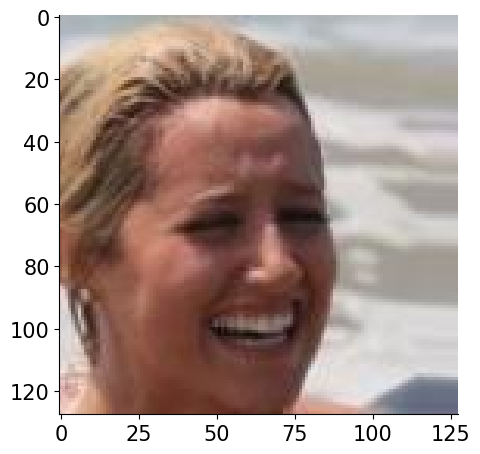

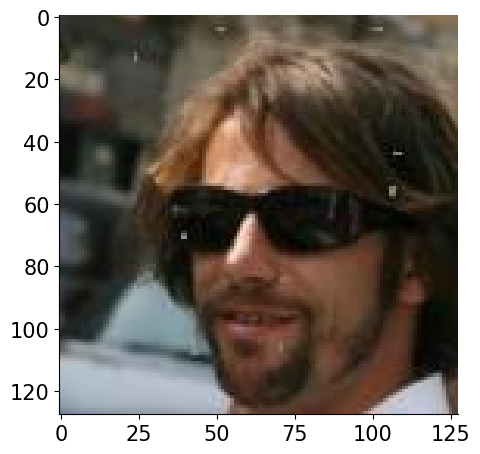

In [26]:
# iterate through dataset and flag images that are not predicted as what we want
distr_types = ["int_hair_0", "int_hair_1", "int_hair_2", "int_hair_3", "int_hair_4"]

for idx, distr_type in enumerate(distr_types):
    if idx == 0:
        hair_categories = ["Gray", "Brown"]
        hair_range = np.arange(2)
    elif idx == 1:
        hair_categories = ["Black", "Blond"]
        hair_range = np.arange(2)
    elif idx == 2:
        hair_categories = ["Black", "Brown"]
        hair_range = np.arange(2)
    elif idx == 3:
        hair_categories = ["Gray"]
        hair_range = np.arange(1)
    elif idx == 4:
        hair_categories = ["Blond"]
        hair_range = np.arange(1)

    distr_root = root / "CausalCelebA" / "chain" / f"dim{img_size}" / distr_type

    # Create dataset and dataloader
    dataset = ImageDataset(distr_root, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    rejected_images = []

    for jdx, (images, file_names) in enumerate(dataloader):
        images = images.to(device)
        
        # load in the file and apply transformation
        # print(images.shape)
        logits, y_pred_probas = model(images)
        # print(logits.shape, y_pred_probas.shape)
        # for prob, file_name in zip(outputs.cpu().numpy(), file_names):
        #     if prob < THRESHOLD:
        #         rejected_images.append(file_name)

        print(y_pred_probas.shape)
        img = images[0, ...]
        # print(img.shape)
        plt.figure()
        plt.imshow(torch.permute(img.cpu(), (1, 2, 0)))

        if jdx > 0:
            assert False

In [35]:
print(y_pred_probas.shape)
y_preds = torch.argmax(y_pred_probas, dim=1)
print(y_preds)
print([hair_map[i] for i in y_preds])
print(file_names)

torch.Size([2, 4])
tensor([0, 3], device='cuda:7')
['Black', 'Gray']
('sample_11921.jpg', 'sample_10960.jpg')


torch.Size([3, 64, 64])
Black
/local/eb/adam2392/CausalCelebA/chain/dim128/int_hair_0/sample_3.jpg


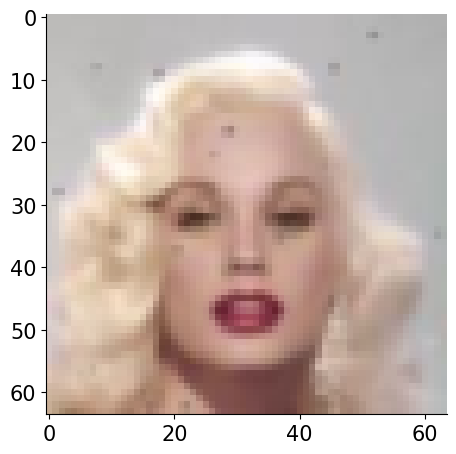

: 

In [ ]:
# img = torch.unsqueeze(img.to(device), 0)
print(img.shape)
(gender_logits, gender_probs), (hair_logits, hair_probs), (age_logits, age_probs) = model(torch.unsqueeze(img.to(device), 0))

hair_encoding = ["Black", "Blond", "Brown", "Gray"]
hair_prediction = torch.argmax(hair_probs)
print(hair_encoding[hair_prediction])
print(filename)
plt.imshow(torch.permute(img, (1, 2, 0)))